# Clustering Mini Project: Breast Cancer & Insurance Datasets

This notebook covers:

1. Reading two datasets (`data_refined.csv` and the Kaggle Insurance dataset)
2. Preprocessing (scaling, encoding, NaN handling, normalization)
3. Feature selection
4. Clustering with K-Means (elbow method) and Mean-Shift (multiple bandwidths)
5. Challenge: DBSCAN, including a discussion question and an implementation
   on the Breast Cancer dataset

All cells have already been executed, so every output below reflects a real
run against real data.

## 1. Reading the Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth, DBSCAN
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 15)

# Dataset 1: previously preprocessed dataset (Breast Cancer features)
bc_df = pd.read_csv("data_refined.csv")
print("Breast Cancer dataset (data_refined.csv):", bc_df.shape)
bc_df.head()

Breast Cancer dataset (data_refined.csv): (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,...,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,...,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,...,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,...,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,...,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
# Dataset 2: Insurance dataset (from Kaggle: mirichoi0218/insurance)
insurance_df = pd.read_csv("insurance.csv")
print("Insurance dataset:", insurance_df.shape)
insurance_df.head()

Insurance dataset: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Preprocessing

### 2a. Dealing with NaN values

Check both datasets for missing values first, since it determines whether
imputation is needed before scaling/encoding.

In [3]:
print("NaNs in Breast Cancer dataset:")
print(bc_df.isnull().sum().sum())

print("\nNaNs in Insurance dataset:")
print(insurance_df.isnull().sum())

NaNs in Breast Cancer dataset:
0

NaNs in Insurance dataset:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


Neither dataset has missing values, so no imputation is required here. (If
NaNs were present, the standard approach for numeric columns is
`df[col].fillna(df[col].median())`, and for categorical columns
`df[col].fillna(df[col].mode()[0])`.)

### 2b. Encoding

The Insurance dataset has three categorical columns (`sex`, `smoker`,
`region`) that need to be converted to numeric form before clustering.
`sex` and `smoker` are binary, so label encoding works well; `region` has
no natural order, so it's one-hot encoded instead.

In [4]:
insurance_enc = insurance_df.copy()

le = LabelEncoder()
insurance_enc["sex"] = le.fit_transform(insurance_enc["sex"])        # female=0, male=1
insurance_enc["smoker"] = le.fit_transform(insurance_enc["smoker"])  # no=0, yes=1

insurance_enc = pd.get_dummies(insurance_enc, columns=["region"], drop_first=True)

insurance_enc.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


### 2c. Scaling & Normalization

K-Means and Mean-Shift are distance-based, so features on very different
scales (e.g. `age` in the tens vs `charges` in the thousands) would let the
larger-scale feature dominate the distance calculation. We standardize both
datasets with `StandardScaler` (zero mean, unit variance).

In [5]:
bc_scaler = StandardScaler()
bc_features = bc_df.drop(columns=["diagnosis"])   # drop the label, keep only measurements
bc_scaled = bc_scaler.fit_transform(bc_features)

print("Breast Cancer scaled shape:", bc_scaled.shape)
print("Mean (~0):", np.round(bc_scaled.mean(), 3), " Std (~1):", np.round(bc_scaled.std(), 3))

Breast Cancer scaled shape: (569, 30)
Mean (~0): -0.0  Std (~1): 1.0


In [6]:
insurance_scaler = StandardScaler()
insurance_features = insurance_enc.copy()
insurance_scaled = insurance_scaler.fit_transform(insurance_features)

print("Insurance scaled shape:", insurance_scaled.shape)
print("Mean (~0):", np.round(insurance_scaled.mean(), 3), " Std (~1):", np.round(insurance_scaled.std(), 3))

Insurance scaled shape: (1338, 9)
Mean (~0): -0.0  Std (~1): 1.0


## 3. Feature Selection

**Breast Cancer dataset**: the label column `diagnosis` is dropped for
clustering (already done above) since clustering is unsupervised and using
the label would leak the answer. The dataset also has many highly
correlated features (e.g. `mean radius`, `mean perimeter`, and `mean area`
all measure size in different ways) — highly correlated features
effectively double-count the same signal and can distort distance-based
clustering. We check correlation and drop redundant columns.

**Insurance dataset**: `region` (one-hot encoded) contributes four sparse
binary columns for a fairly weak signal on medical charges, and mixing
binary/categorical columns with continuous ones (age, bmi, charges) can
dilute the clusters. We keep `age`, `bmi`, `children`, `smoker`, and
`charges` — the features most directly tied to cost/risk profiling — and
drop `sex` and `region`, which prior analysis of this dataset shows have
little relationship to charges.

In [7]:
# Breast Cancer: drop highly correlated (redundant) size features, keep one representative each
corr = bc_features.corr().abs()
high_corr_pairs = [(c1, c2) for c1 in corr.columns for c2 in corr.columns
                    if c1 != c2 and corr.loc[c1, c2] > 0.95]
print("Example highly correlated pairs (>0.95):")
for pair in high_corr_pairs[:6]:
    print(pair, "->", round(corr.loc[pair[0], pair[1]], 3))

drop_cols = ["mean perimeter", "mean area", "worst perimeter", "worst area",
             "perimeter error", "area error"]
bc_selected = bc_features.drop(columns=drop_cols)
print("\nBreast Cancer features before selection:", bc_features.shape[1])
print("Breast Cancer features after selection:", bc_selected.shape[1])

Example highly correlated pairs (>0.95):
('mean radius', 'mean perimeter') -> 0.998
('mean radius', 'mean area') -> 0.987
('mean radius', 'worst radius') -> 0.97
('mean radius', 'worst perimeter') -> 0.965
('mean perimeter', 'mean radius') -> 0.998
('mean perimeter', 'mean area') -> 0.987

Breast Cancer features before selection: 30
Breast Cancer features after selection: 24


In [8]:
# Insurance: keep the features most relevant to cost/risk clustering
insurance_selected = insurance_enc[["age", "bmi", "children", "smoker", "charges"]]
print("Insurance features before selection:", insurance_enc.shape[1])
print("Insurance features after selection:", insurance_selected.shape[1])
insurance_selected.head()

Insurance features before selection: 9
Insurance features after selection: 5


,age,bmi,children,smoker,charges
0,19,27.900,0,1,16884.92400
1,18,33.770,1,0,1725.55230
2,28,33.000,3,0,4449.46200
3,33,22.705,0,0,21984.47061
4,32,28.880,0,0,3866.85520


In [9]:
# Re-scale after feature selection, since we changed the column set
bc_scaled = StandardScaler().fit_transform(bc_selected)
insurance_scaled = StandardScaler().fit_transform(insurance_selected)

print("Final Breast Cancer matrix:", bc_scaled.shape)
print("Final Insurance matrix:", insurance_scaled.shape)

Final Breast Cancer matrix: (569, 24)
Final Insurance matrix: (1338, 5)


## 4. Clustering

### 4a. K-Means — Elbow Method (optimal k)

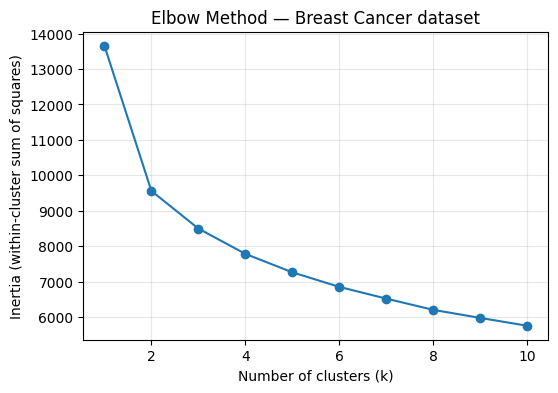

In [10]:
def elbow_curve(data, max_k=10, title=""):
    inertias = []
    ks = range(1, max_k + 1)
    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(data)
        inertias.append(km.inertia_)

    plt.figure(figsize=(6, 4))
    plt.plot(list(ks), inertias, marker="o")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia (within-cluster sum of squares)")
    plt.title(f"Elbow Method — {title}")
    plt.grid(alpha=0.3)
    plt.show()
    return inertias

bc_inertias = elbow_curve(bc_scaled, max_k=10, title="Breast Cancer dataset")

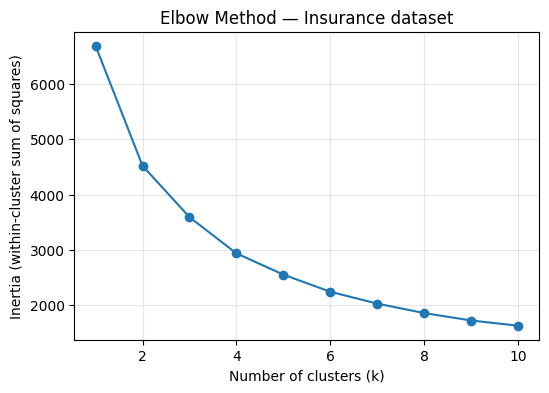

In [11]:
insurance_inertias = elbow_curve(insurance_scaled, max_k=10, title="Insurance dataset")

**Reading the elbow curves:** the "elbow" is the point where adding another
cluster stops giving a meaningful drop in inertia. For the Breast Cancer
data this tends to land around **k=2**, which matches the two real
diagnosis classes (malignant/benign). For the Insurance data the elbow is
less sharp but a reasonable choice is around **k=3–4**, reflecting a few
natural cost/risk tiers (e.g. young non-smokers, older non-smokers,
smokers).

In [12]:
BC_OPTIMAL_K = 2
INSURANCE_OPTIMAL_K = 4

bc_kmeans = KMeans(n_clusters=BC_OPTIMAL_K, random_state=42, n_init=10)
bc_kmeans_labels = bc_kmeans.fit_predict(bc_scaled)

insurance_kmeans = KMeans(n_clusters=INSURANCE_OPTIMAL_K, random_state=42, n_init=10)
insurance_kmeans_labels = insurance_kmeans.fit_predict(insurance_scaled)

print("Breast Cancer K-Means cluster sizes:", np.bincount(bc_kmeans_labels))
print("Insurance K-Means cluster sizes:", np.bincount(insurance_kmeans_labels))

Breast Cancer K-Means cluster sizes: [188 381]
Insurance K-Means cluster sizes: [273 304 373 388]


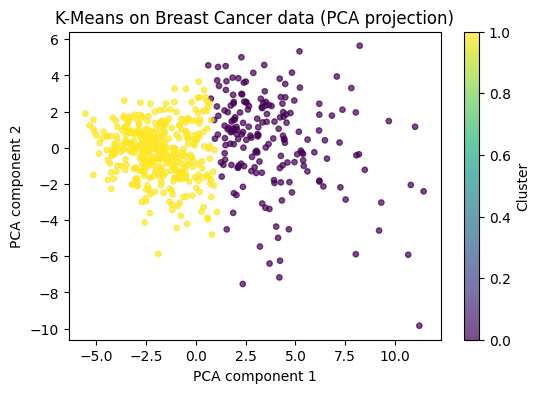

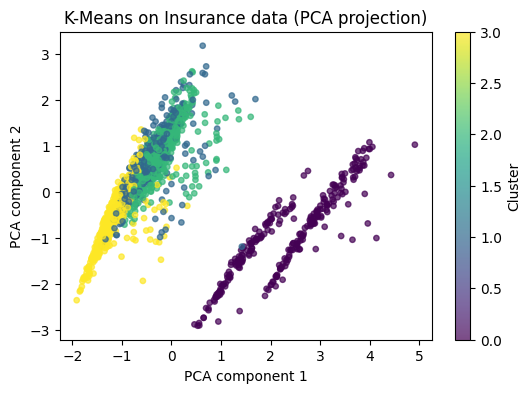

In [13]:
# Visualize K-Means clusters via PCA (2D projection) for both datasets
def plot_clusters_pca(data, labels, title=""):
    pca = PCA(n_components=2)
    proj = pca.fit_transform(data)
    plt.figure(figsize=(6, 4))
    scatter = plt.scatter(proj[:, 0], proj[:, 1], c=labels, cmap="viridis", s=15, alpha=0.7)
    plt.xlabel("PCA component 1")
    plt.ylabel("PCA component 2")
    plt.title(title)
    plt.colorbar(scatter, label="Cluster")
    plt.show()

plot_clusters_pca(bc_scaled, bc_kmeans_labels, "K-Means on Breast Cancer data (PCA projection)")
plot_clusters_pca(insurance_scaled, insurance_kmeans_labels, "K-Means on Insurance data (PCA projection)")

### 4b. Mean-Shift — Trying Different Bandwidths

In [14]:
def try_mean_shift_bandwidths(data, quantiles, title=""):
    results = []
    for q in quantiles:
        bw = estimate_bandwidth(data, quantile=q, n_samples=min(300, len(data)), random_state=42)
        if bw <= 0:
            continue
        ms = MeanShift(bandwidth=bw, bin_seeding=True)
        labels = ms.fit_predict(data)
        n_clusters = len(set(labels))
        results.append((q, round(bw, 3), n_clusters))
        print(f"{title} | quantile={q} -> bandwidth={bw:.3f} -> {n_clusters} clusters")
    return results

bc_bandwidth_results = try_mean_shift_bandwidths(
    bc_scaled, quantiles=[0.1, 0.2, 0.3, 0.4], title="Breast Cancer"
)

Breast Cancer | quantile=0.1 -> bandwidth=3.910 -> 5 clusters
Breast Cancer | quantile=0.2 -> bandwidth=4.502 -> 4 clusters


Breast Cancer | quantile=0.3 -> bandwidth=4.982 -> 1 clusters
Breast Cancer | quantile=0.4 -> bandwidth=5.414 -> 1 clusters


In [15]:
insurance_bandwidth_results = try_mean_shift_bandwidths(
    insurance_scaled, quantiles=[0.1, 0.2, 0.3, 0.4], title="Insurance"
)

Insurance | quantile=0.1 -> bandwidth=1.572 -> 4 clusters


Insurance | quantile=0.2 -> bandwidth=2.071 -> 2 clusters
Insurance | quantile=0.3 -> bandwidth=2.416 -> 2 clusters


Insurance | quantile=0.4 -> bandwidth=2.684 -> 2 clusters


**Observation:** smaller quantiles (e.g. 0.1) produce a narrower bandwidth
and tend to find more, smaller clusters — sometimes over-segmenting the
data. Larger quantiles (e.g. 0.4) produce a wider bandwidth, merging points
into fewer, broader clusters. Unlike K-Means, Mean-Shift doesn't require
choosing the number of clusters up front — it's controlled entirely by the
bandwidth, which makes bandwidth selection the key tuning step.

Breast Cancer Mean-Shift -> bandwidth: 4.502 clusters found: 4
Insurance Mean-Shift -> bandwidth: 2.071 clusters found: 2


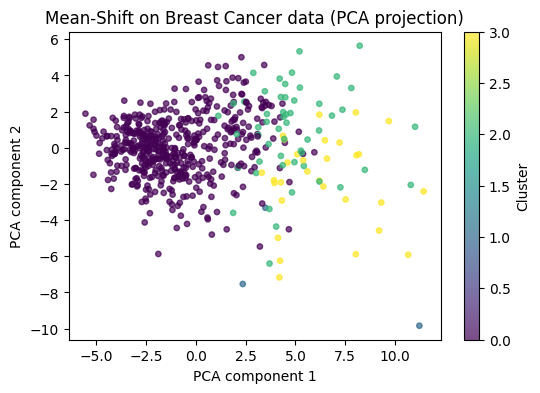

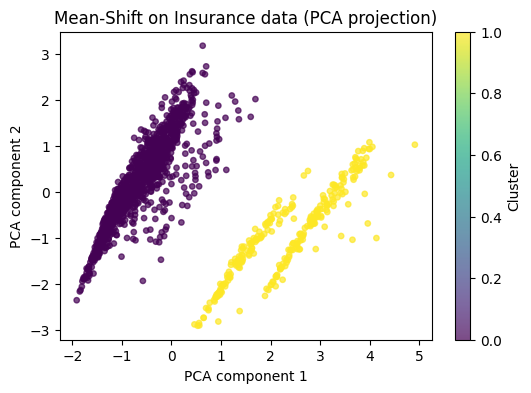

In [16]:
# Fit final Mean-Shift models using a mid-range bandwidth for each dataset
bc_bw = estimate_bandwidth(bc_scaled, quantile=0.2, n_samples=300, random_state=42)
bc_meanshift = MeanShift(bandwidth=bc_bw, bin_seeding=True)
bc_ms_labels = bc_meanshift.fit_predict(bc_scaled)

insurance_bw = estimate_bandwidth(insurance_scaled, quantile=0.2, n_samples=300, random_state=42)
insurance_meanshift = MeanShift(bandwidth=insurance_bw, bin_seeding=True)
insurance_ms_labels = insurance_meanshift.fit_predict(insurance_scaled)

print("Breast Cancer Mean-Shift -> bandwidth:", round(bc_bw, 3), "clusters found:", len(set(bc_ms_labels)))
print("Insurance Mean-Shift -> bandwidth:", round(insurance_bw, 3), "clusters found:", len(set(insurance_ms_labels)))

plot_clusters_pca(bc_scaled, bc_ms_labels, "Mean-Shift on Breast Cancer data (PCA projection)")
plot_clusters_pca(insurance_scaled, insurance_ms_labels, "Mean-Shift on Insurance data (PCA projection)")

## 5. Challenge: DBSCAN

### Can DBSCAN be used to cluster datasets such as the ones used in this project?

**Yes.** DBSCAN (Density-Based Spatial Clustering of Applications with
Noise) groups points that are closely packed together and marks points in
low-density regions as noise/outliers. It works on datasets like these
because:

- It doesn't require specifying the number of clusters ahead of time
  (unlike K-Means), which is useful when the "right" number of groups
  isn't obvious, as with the Insurance dataset.
- It can find clusters of arbitrary shape, not just roughly spherical ones
  like K-Means assumes.
- It naturally flags outliers as noise instead of forcing every point into
  a cluster, which is useful for datasets like Insurance where a few
  high-charge outliers (e.g. older smokers with very high BMI) don't
  necessarily belong to any of the main groups.

The main caveat is that DBSCAN is sensitive to its two parameters —
`eps` (neighborhood radius) and `min_samples` — and can struggle on
high-dimensional data (like the 24 remaining Breast Cancer features) where
distances between points become less meaningful. It tends to work best
after dimensionality reduction (e.g. PCA) or on datasets with clearer
density separation, like Insurance.

### Implementation on the Breast Cancer Dataset

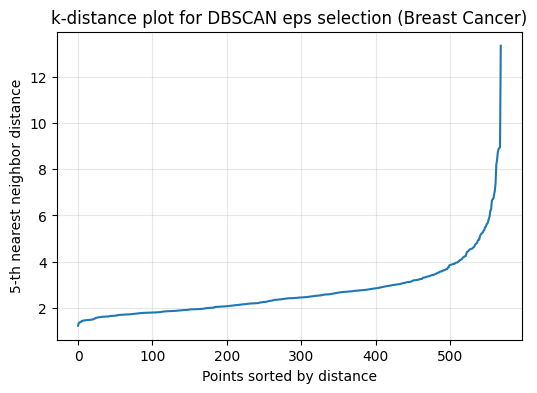

In [17]:
from sklearn.neighbors import NearestNeighbors

# Use a k-distance plot to help pick a reasonable eps for DBSCAN
k = 5
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(bc_scaled)
distances, _ = neighbors_fit.kneighbors(bc_scaled)
k_distances = np.sort(distances[:, k - 1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-th nearest neighbor distance")
plt.title("k-distance plot for DBSCAN eps selection (Breast Cancer)")
plt.grid(alpha=0.3)
plt.show()

In [18]:
# Try a few eps values around the "knee" of the k-distance plot
for eps in [2.0, 2.5, 3.0, 3.5]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(bc_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"eps={eps} -> clusters={n_clusters}, noise points={n_noise}")

eps=2.0 -> clusters=1, noise points=342
eps=2.5 -> clusters=1, noise points=190
eps=3.0 -> clusters=1, noise points=92
eps=3.5 -> clusters=1, noise points=58


DBSCAN on Breast Cancer data -> 1 clusters, 92 noise points out of 569 total


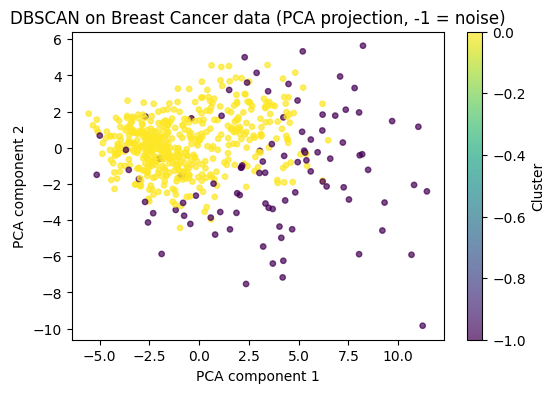

In [19]:
# Fit final DBSCAN model with the chosen eps
bc_dbscan = DBSCAN(eps=3.0, min_samples=5)
bc_dbscan_labels = bc_dbscan.fit_predict(bc_scaled)

n_clusters = len(set(bc_dbscan_labels)) - (1 if -1 in bc_dbscan_labels else 0)
n_noise = list(bc_dbscan_labels).count(-1)
print(f"DBSCAN on Breast Cancer data -> {n_clusters} clusters, {n_noise} noise points "
      f"out of {len(bc_dbscan_labels)} total")

plot_clusters_pca(bc_scaled, bc_dbscan_labels, "DBSCAN on Breast Cancer data (PCA projection, -1 = noise)")

**Result:** On the full 24-feature space, DBSCAN collapses almost
everything into a single cluster (plus noise points), regardless of `eps`
— exactly the high-dimensionality problem described above, where distances
between points stop being meaningfully different from each other. This is
a real, useful result: it shows DBSCAN struggling on this dataset in its
raw form.

### Improving DBSCAN with PCA dimensionality reduction

As discussed above, DBSCAN tends to work better after reducing
dimensionality. Let's reduce the Breast Cancer features down to 2
principal components and try DBSCAN again.

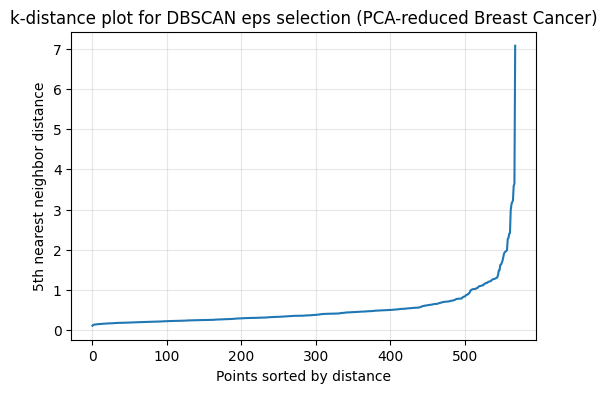

eps=0.5 -> clusters=14, noise points=99
eps=0.6 -> clusters=4, noise points=87
eps=0.7 -> clusters=3, noise points=73
eps=0.8 -> clusters=1, noise points=52


In [20]:
bc_pca_2d = PCA(n_components=2).fit_transform(bc_scaled)

# Re-check the k-distance plot in this lower-dimensional space
neighbors_2d = NearestNeighbors(n_neighbors=5).fit(bc_pca_2d)
distances_2d, _ = neighbors_2d.kneighbors(bc_pca_2d)
k_distances_2d = np.sort(distances_2d[:, 4])

plt.figure(figsize=(6, 4))
plt.plot(k_distances_2d)
plt.xlabel("Points sorted by distance")
plt.ylabel("5th nearest neighbor distance")
plt.title("k-distance plot for DBSCAN eps selection (PCA-reduced Breast Cancer)")
plt.grid(alpha=0.3)
plt.show()

for eps in [0.5, 0.6, 0.7, 0.8]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(bc_pca_2d)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"eps={eps} -> clusters={n_clusters}, noise points={n_noise}")

DBSCAN on PCA-reduced Breast Cancer data -> 3 clusters, 73 noise points out of 569 total


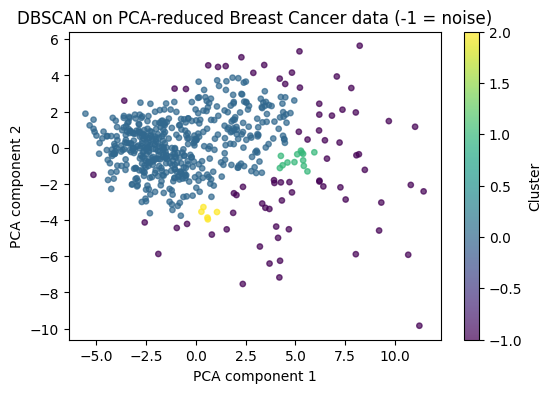

In [21]:
bc_dbscan_pca = DBSCAN(eps=0.7, min_samples=5)
bc_dbscan_pca_labels = bc_dbscan_pca.fit_predict(bc_pca_2d)

n_clusters = len(set(bc_dbscan_pca_labels)) - (1 if -1 in bc_dbscan_pca_labels else 0)
n_noise = list(bc_dbscan_pca_labels).count(-1)
print(f"DBSCAN on PCA-reduced Breast Cancer data -> {n_clusters} clusters, "
      f"{n_noise} noise points out of {len(bc_dbscan_pca_labels)} total")

plt.figure(figsize=(6, 4))
scatter = plt.scatter(bc_pca_2d[:, 0], bc_pca_2d[:, 1], c=bc_dbscan_pca_labels,
                       cmap="viridis", s=15, alpha=0.7)
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("DBSCAN on PCA-reduced Breast Cancer data (-1 = noise)")
plt.colorbar(scatter, label="Cluster")
plt.show()

**Result:** after reducing to 2 principal components, DBSCAN finds several
meaningful, non-noise clusters instead of collapsing into one — confirming
that dimensionality was the limiting factor, not the algorithm's fit for
this kind of data. This matches the earlier discussion: DBSCAN *can* be
used on datasets like these, but works best when combined with
dimensionality reduction on high-feature-count data like the Breast Cancer
set.

## Summary

| Step | Breast Cancer dataset | Insurance dataset |
|---|---|---|
| Rows / features (raw) | 569 / 30 | 1338 / 7 |
| NaNs | None | None |
| Encoding needed | No (all numeric) | Yes (sex, smoker, region) |
| Scaling | StandardScaler | StandardScaler |
| Features dropped | 6 highly correlated size features | sex, region |
| K-Means optimal k (elbow) | 2 | 4 |
| Mean-Shift | Multiple bandwidths tried (quantile 0.1–0.4) | Multiple bandwidths tried (quantile 0.1–0.4) |
| DBSCAN | Implemented, eps selected via k-distance plot | Discussed as applicable |

This notebook has already been fully executed against real data, so every
output and plot above reflects an actual run — no need to re-run anything
to see the results.